---
title: "Data Science Concept: Cholesky Decomposition"
date: "2021-09-14"
categories: [data science]
slug: "20210914-cholesky-decomposition"
description: "Cholesky decomposition breaks a matrix into triangular parts. Useful for solving linear systems, simulating correlated variables, and speeding up optimization."
---



## Definition

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use(['science','ieee', 'notebook'])
pct_fmt = mtick.FormatStrFormatter('.0f%')

In [8]:
## Download data.
price_df = yf.download('FNGD XLF SPY', start="2021-01-01", end="2022-02-20")
price_df = price_df['Close'].div(price_df['Close'].iloc[0])
returns_df = price_df.pct_change()

[*********************100%***********************]  3 of 3 completed


In [9]:
## Strategy.
returns_df['XLF+FNGD'] = returns_df['FNGD'] + returns_df['XLF']

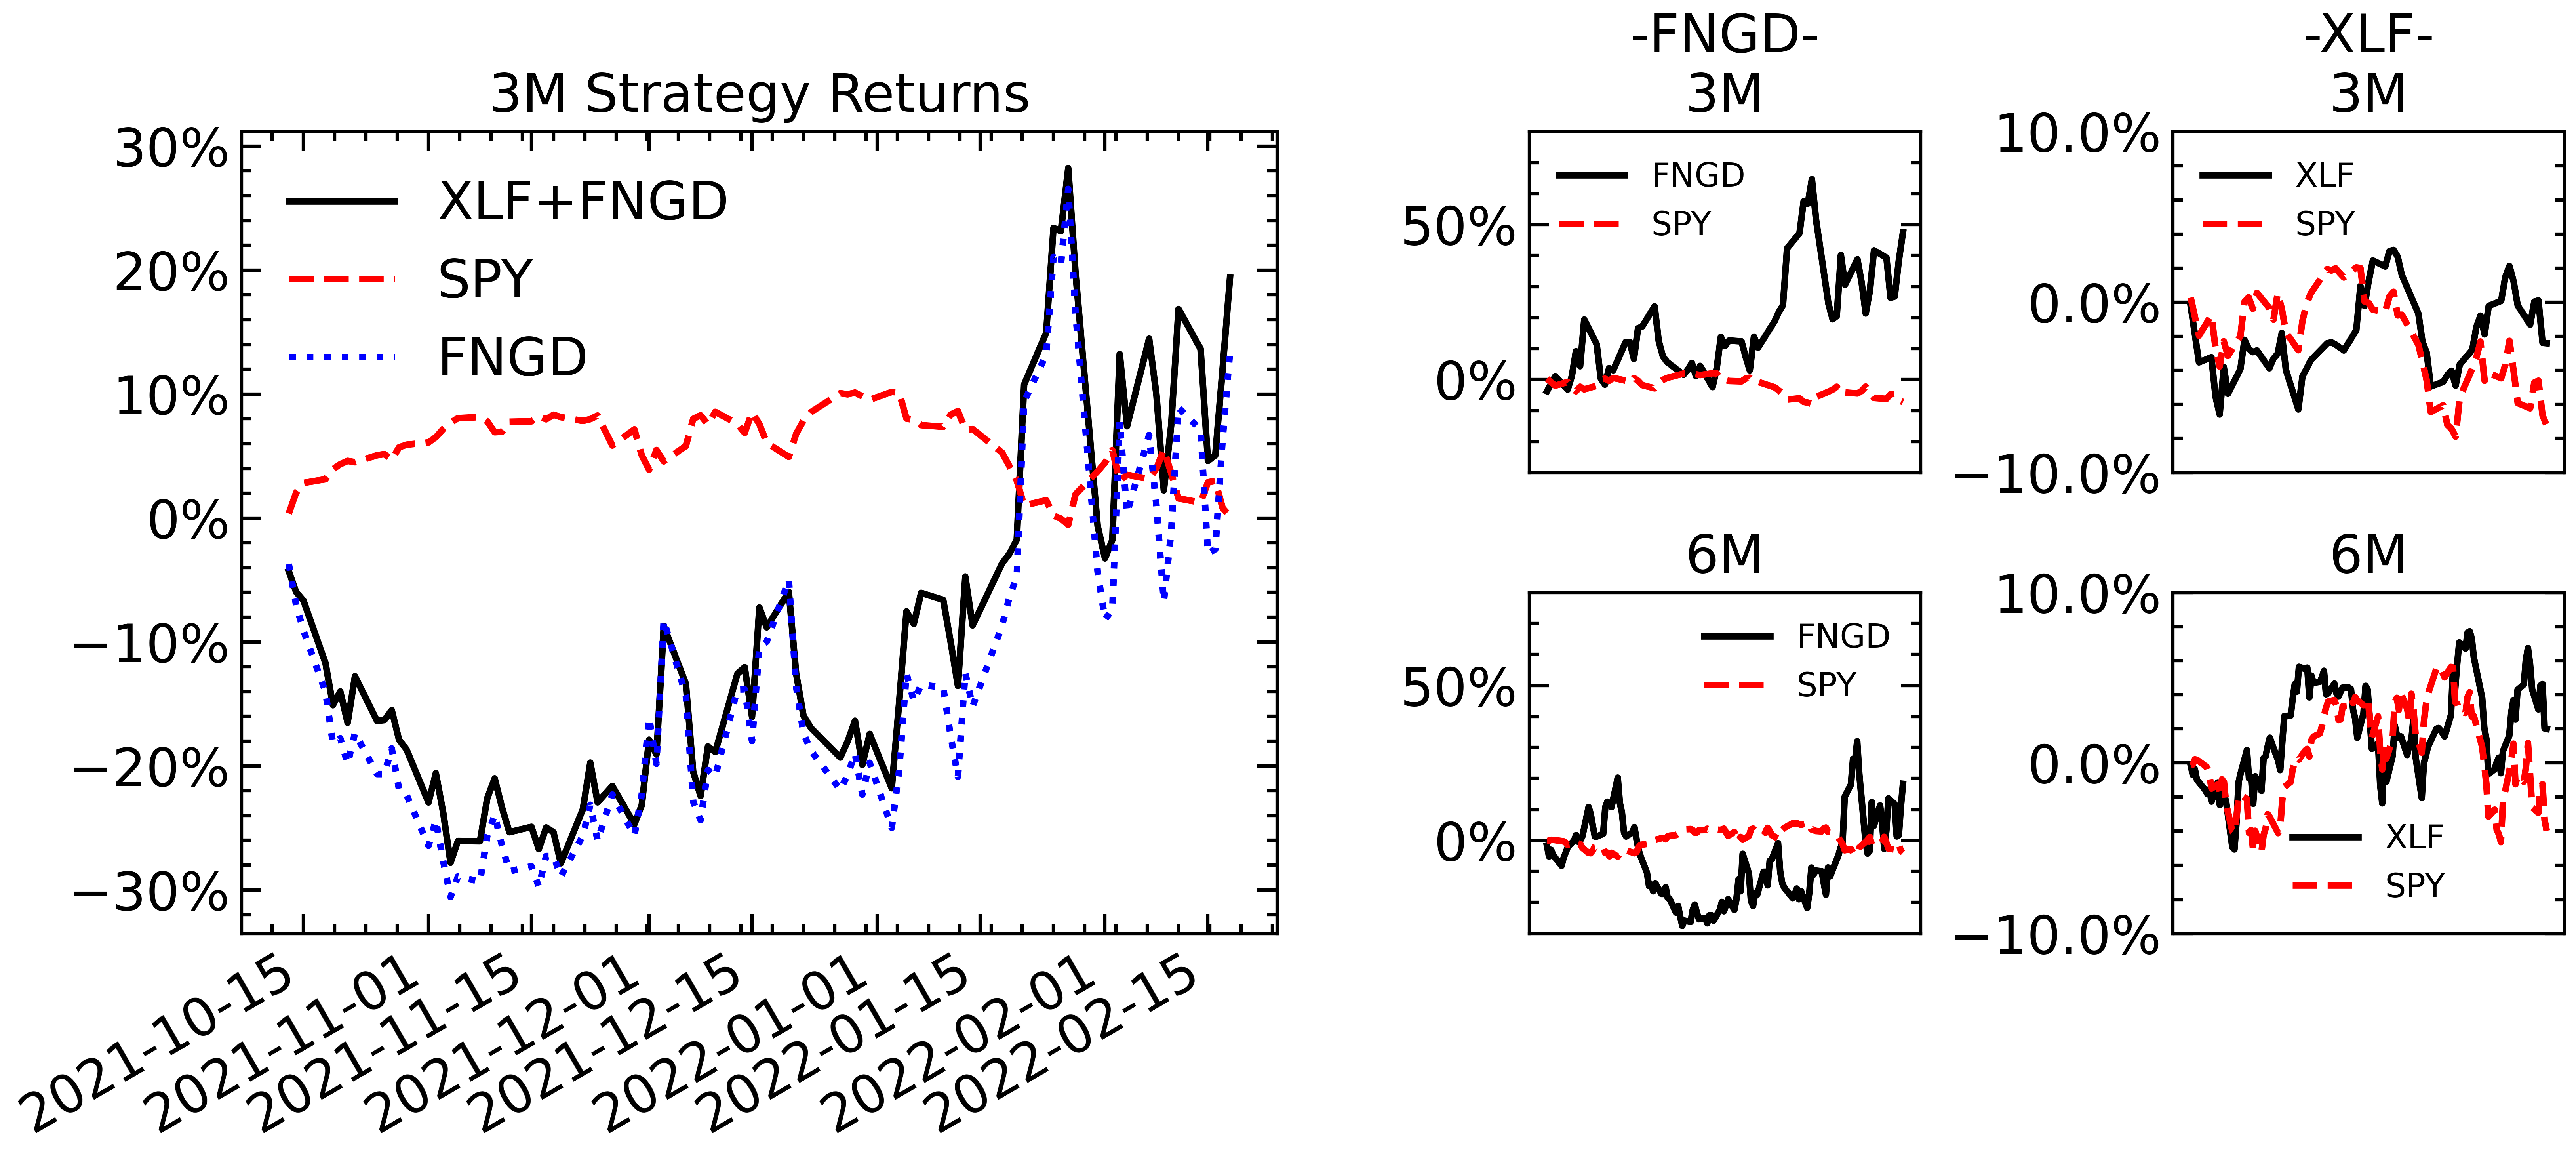

In [12]:
mozaic = """
AABD
AACE
"""

fig, axs = plt.subplot_mosaic(mozaic, figsize=(11,5))

## Strategy plot.
((1+returns_df[['XLF+FNGD', 'SPY', 'FNGD']].tail(90)).cumprod() - 1).plot(ax=axs['A'])
axs['A'].set_title('3M Strategy Returns')
axs['A'].set_xlabel('')
axs['A'].yaxis.set_major_formatter(mtick.PercentFormatter(1.))

## FANGD.
((1+returns_df[['FNGD', 'SPY']].tail(60)).cumprod() - 1).plot(ax=axs['B'])
axs['B'].set_title('-FNGD-\n3M')
axs['B'].set_xlabel('')
axs['B'].yaxis.set_major_formatter(mtick.PercentFormatter(1.))
axs['B'].xaxis.set_major_locator(plt.NullLocator())
axs['B'].set_ylim([-0.3, 0.8])
axs['B'].legend(fontsize=10)

((1+returns_df[['FNGD', 'SPY']].tail(120)).cumprod() - 1).plot(ax=axs['C'])
axs['C'].set_title('6M')
axs['C'].set_xlabel('')
axs['C'].yaxis.set_major_formatter(mtick.PercentFormatter(1.))
axs['C'].xaxis.set_major_locator(plt.NullLocator())
axs['C'].set_ylim([-0.3, 0.8])
axs['C'].legend(fontsize=10)

## FANGD.
((1+returns_df[['XLF', 'SPY']].tail(60)).cumprod() - 1).plot(ax=axs['D'])
axs['D'].set_title('-XLF-\n3M')
axs['D'].set_xlabel('')
axs['D'].yaxis.set_major_formatter(mtick.PercentFormatter(1.))
axs['D'].xaxis.set_major_locator(plt.NullLocator())
axs['D'].set_ylim([-0.1, 0.1])
axs['D'].legend(fontsize=10)

((1+returns_df[['XLF', 'SPY']].tail(120)).cumprod() - 1).plot(ax=axs['E'])
axs['E'].set_title('6M')
axs['E'].set_xlabel('')
axs['E'].yaxis.set_major_formatter(mtick.PercentFormatter(1.))
axs['E'].xaxis.set_major_locator(plt.NullLocator())
axs['E'].set_ylim([-0.1, 0.1])
axs['E'].legend(fontsize=10)

fig.tight_layout();

In [13]:
X = returns_df['XLF+FNGD'].dropna()
y = returns_df['SPY'].dropna()

beta = np.cov([X, y])[1][0] / np.cov([X, y])[1][1]
corr = np.corrcoef(X, y)[0][1]

beta, corr

(-3.5012961304830315, -0.622963207458605)